In [7]:
import copy
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import numpy as np

In [9]:
#NN model
#1 hidden layer, 32 nuerons
#uses full batch gradient descent to update weights
class RegressionNN(nn.Module):
    def __init__(self, input_size):
        super(RegressionNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x)) #using ReLU activation function
        x = self.output(x)
        return x

In [11]:
#Training
def train_model(X_train, y_train, X_val, y_val, n_epochs=1000): #max iteration 1,000
    model = RegressionNN(X_train.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001) #dynamic learning rate 0.001 - recommended, optimized with an adaptive learning rate
    #the closer it gets to the local min the smaller the jumps.
    
    # For plotting
    train_losses = []
    val_losses = []
    
    for epoch in range(n_epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_losses.append(val_loss.item())
        
        if (epoch+1) % 20 == 0:
            print(f'Epoch {epoch+1}/{n_epochs} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}')
    
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.show()
    
    return model

In [13]:
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test)
        
        # Convert to numpy for sklearn metrics
        y_true = y_test.numpy().flatten()
        y_pred = predictions.numpy().flatten()
        
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        print(f'\nEvaluation Metrics:')
        print(f'MSE: {mse:.4f}')
        print(f'MAE: {mae:.4f}')
        print(f'R2 Score: {r2:.4f}')
        
        # Plot predictions vs actual
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true, y_pred, alpha=0.5)
        plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title('Actual vs Predicted Values')
        plt.show()

In [15]:
def kfold_cross_validation(X, y, n_splits=20, n_epochs=1000):
    # Perform k-fold cross validation and return the best model
    # Returns:
    #     tuple: (best_model, fold_results, avg_metrics)
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    best_model = None
    best_mse = float('inf')
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f'\n{"="*40}')
        print(f'Fold {fold+1}/{n_splits}')
        print(f'{"="*40}')
        
        # Split data
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Convert to tensors
        X_train = torch.FloatTensor(X_train)
        X_val = torch.FloatTensor(X_val)
        y_train = torch.FloatTensor(y_train).view(-1, 1)
        y_val = torch.FloatTensor(y_val).view(-1, 1)
        
        # Train model
        model = train_model(X_train, y_train, X_val, y_val, n_epochs)
        
        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            predictions = model(X_val)
            mse = mean_squared_error(y_val.numpy(), predictions.numpy())
            r2 = r2_score(y_val.numpy(), predictions.numpy())
            mae = mean_absolute_error(y_val.numpy(), predictions.numpy())
            
            # Track best model
            if mse < best_mse:
                best_mse = mse
                best_model = copy.deepcopy(model)
                print(f"New best model found with MSE: {mse:.4f}")
            
            fold_results.append({
                'fold': fold+1,
                'mse': mse,
                'mae': mae,
                'r2': r2,
                'model': model
            })
            
        print(f'Validation Metrics - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}')
    
    # Calculate average metrics
    avg_metrics = {
        'avg_mse': np.mean([res['mse'] for res in fold_results]),
        'avg_mae': np.mean([res['mae'] for res in fold_results]),
        'avg_r2': np.mean([res['r2'] for res in fold_results])
    }
    
    print(f'\n{"="*40}')
    print('Cross-Validation Summary:')
    print(f'Average MSE: {avg_metrics["avg_mse"]:.4f}')
    print(f'Average MAE: {avg_metrics["avg_mae"]:.4f}')
    print(f'Average R2: {avg_metrics["avg_r2"]:.4f}')
    print(f'Best Model MSE: {best_mse:.4f}')
    print(f'{"="*40}')
    
    return best_model, fold_results, avg_metrics

In [17]:
#Prepare data for input into model
def prepare_data(X): 
    cols_to_drop = ["gid","visteam","hometeam","date","teamID","site", "wteam", "lteam"]
    X = X.drop(cols_to_drop, axis=1)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    return X

In [19]:
train = pd.read_csv("../CleanData/full_train.csv")
test = pd.read_csv("../CleanData/full_test.csv")

y_train = train["score_diff"].to_numpy() #converting to numpy aray
x_train = prepare_data(train.drop("score_diff",axis=1)) #dtype nmpy array

y_test = test["score_diff"].to_numpy()
x_test = prepare_data(test.drop("score_diff",axis=1)) #dtype nmpy array


Running K-Fold Cross Validation:

Fold 1/20
Epoch 20/1000 | Train Loss: 18.3663 | Val Loss: 18.2730
Epoch 40/1000 | Train Loss: 17.6285 | Val Loss: 17.5379
Epoch 60/1000 | Train Loss: 16.6734 | Val Loss: 16.6143
Epoch 80/1000 | Train Loss: 15.5790 | Val Loss: 15.5569
Epoch 100/1000 | Train Loss: 14.4799 | Val Loss: 14.4791
Epoch 120/1000 | Train Loss: 13.4784 | Val Loss: 13.4893
Epoch 140/1000 | Train Loss: 12.5952 | Val Loss: 12.6019
Epoch 160/1000 | Train Loss: 11.7831 | Val Loss: 11.7751
Epoch 180/1000 | Train Loss: 10.9822 | Val Loss: 10.9613
Epoch 200/1000 | Train Loss: 10.1597 | Val Loss: 10.1305
Epoch 220/1000 | Train Loss: 9.3270 | Val Loss: 9.2929
Epoch 240/1000 | Train Loss: 8.5141 | Val Loss: 8.4708
Epoch 260/1000 | Train Loss: 7.7370 | Val Loss: 7.7015
Epoch 280/1000 | Train Loss: 6.9820 | Val Loss: 6.9571
Epoch 300/1000 | Train Loss: 6.2499 | Val Loss: 6.2446
Epoch 320/1000 | Train Loss: 5.5530 | Val Loss: 5.5633
Epoch 340/1000 | Train Loss: 4.9006 | Val Loss: 4.9319
Epoc

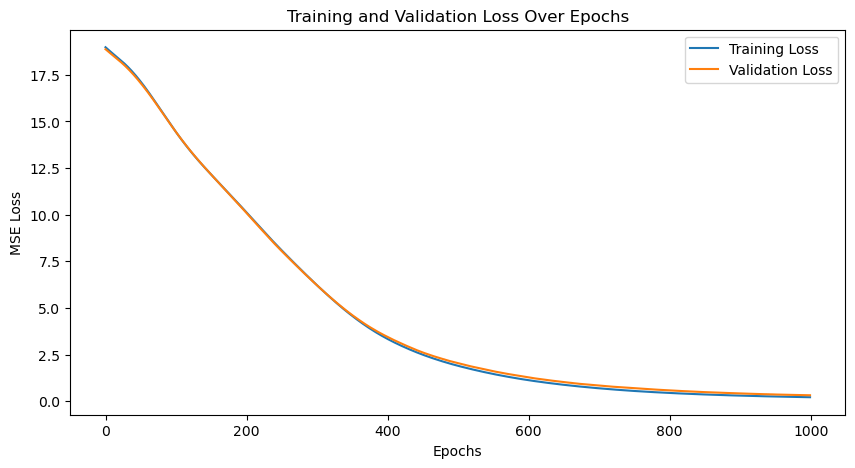

New best model found with MSE: 0.3209
Validation Metrics - MSE: 0.3209, MAE: 0.2210, R2: 0.9830

Fold 2/20
Epoch 20/1000 | Train Loss: 18.4866 | Val Loss: 17.9952
Epoch 40/1000 | Train Loss: 17.7241 | Val Loss: 17.2403
Epoch 60/1000 | Train Loss: 16.7158 | Val Loss: 16.2236
Epoch 80/1000 | Train Loss: 15.5555 | Val Loss: 15.0693
Epoch 100/1000 | Train Loss: 14.3894 | Val Loss: 13.9173
Epoch 120/1000 | Train Loss: 13.2983 | Val Loss: 12.8518
Epoch 140/1000 | Train Loss: 12.2793 | Val Loss: 11.8665
Epoch 160/1000 | Train Loss: 11.2944 | Val Loss: 10.9040
Epoch 180/1000 | Train Loss: 10.3600 | Val Loss: 9.9903
Epoch 200/1000 | Train Loss: 9.4837 | Val Loss: 9.1414
Epoch 220/1000 | Train Loss: 8.6715 | Val Loss: 8.3435
Epoch 240/1000 | Train Loss: 7.8972 | Val Loss: 7.5781
Epoch 260/1000 | Train Loss: 7.1446 | Val Loss: 6.8410
Epoch 280/1000 | Train Loss: 6.4243 | Val Loss: 6.1444
Epoch 300/1000 | Train Loss: 5.7438 | Val Loss: 5.4824
Epoch 320/1000 | Train Loss: 5.1061 | Val Loss: 4.8567


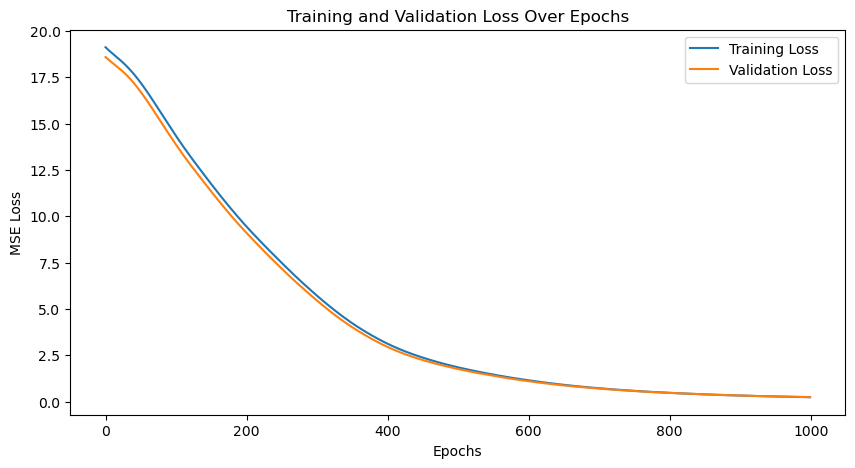

New best model found with MSE: 0.2449
Validation Metrics - MSE: 0.2449, MAE: 0.2241, R2: 0.9867

Fold 3/20
Epoch 20/1000 | Train Loss: 18.4497 | Val Loss: 18.5987
Epoch 40/1000 | Train Loss: 17.7321 | Val Loss: 17.8722
Epoch 60/1000 | Train Loss: 16.8207 | Val Loss: 16.9549
Epoch 80/1000 | Train Loss: 15.7601 | Val Loss: 15.8975
Epoch 100/1000 | Train Loss: 14.6643 | Val Loss: 14.7911
Epoch 120/1000 | Train Loss: 13.6331 | Val Loss: 13.7285
Epoch 140/1000 | Train Loss: 12.6760 | Val Loss: 12.7454
Epoch 160/1000 | Train Loss: 11.7504 | Val Loss: 11.7925
Epoch 180/1000 | Train Loss: 10.8368 | Val Loss: 10.8610
Epoch 200/1000 | Train Loss: 9.9513 | Val Loss: 9.9518
Epoch 220/1000 | Train Loss: 9.0908 | Val Loss: 9.0651
Epoch 240/1000 | Train Loss: 8.2292 | Val Loss: 8.1890
Epoch 260/1000 | Train Loss: 7.3871 | Val Loss: 7.3474
Epoch 280/1000 | Train Loss: 6.5962 | Val Loss: 6.5748
Epoch 300/1000 | Train Loss: 5.8557 | Val Loss: 5.8489
Epoch 320/1000 | Train Loss: 5.1713 | Val Loss: 5.1750

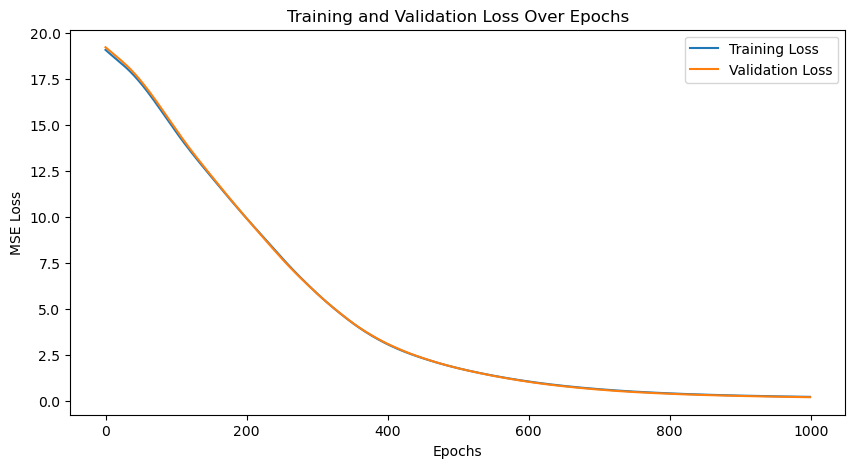

New best model found with MSE: 0.1795
Validation Metrics - MSE: 0.1795, MAE: 0.2075, R2: 0.9906

Fold 4/20
Epoch 20/1000 | Train Loss: 18.3810 | Val Loss: 19.1832
Epoch 40/1000 | Train Loss: 17.5808 | Val Loss: 18.3909
Epoch 60/1000 | Train Loss: 16.5227 | Val Loss: 17.3527
Epoch 80/1000 | Train Loss: 15.3622 | Val Loss: 16.2301
Epoch 100/1000 | Train Loss: 14.2757 | Val Loss: 15.1869
Epoch 120/1000 | Train Loss: 13.3240 | Val Loss: 14.2647
Epoch 140/1000 | Train Loss: 12.4468 | Val Loss: 13.3909
Epoch 160/1000 | Train Loss: 11.5707 | Val Loss: 12.4809
Epoch 180/1000 | Train Loss: 10.6757 | Val Loss: 11.5334
Epoch 200/1000 | Train Loss: 9.7749 | Val Loss: 10.5791
Epoch 220/1000 | Train Loss: 8.8927 | Val Loss: 9.6402
Epoch 240/1000 | Train Loss: 8.0522 | Val Loss: 8.7337
Epoch 260/1000 | Train Loss: 7.2637 | Val Loss: 7.8987
Epoch 280/1000 | Train Loss: 6.5190 | Val Loss: 7.1080
Epoch 300/1000 | Train Loss: 5.7995 | Val Loss: 6.3417
Epoch 320/1000 | Train Loss: 5.1267 | Val Loss: 5.625

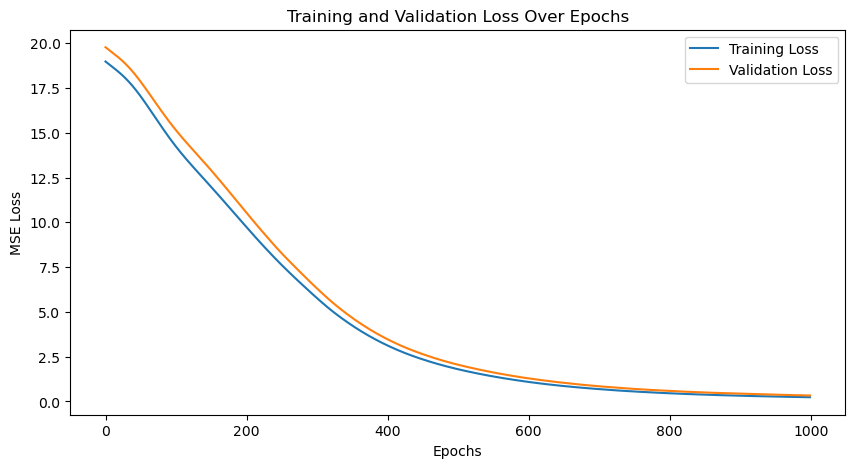

Validation Metrics - MSE: 0.3351, MAE: 0.2492, R2: 0.9831

Fold 5/20
Epoch 20/1000 | Train Loss: 18.5908 | Val Loss: 18.1793
Epoch 40/1000 | Train Loss: 17.9486 | Val Loss: 17.5640
Epoch 60/1000 | Train Loss: 17.0241 | Val Loss: 16.6793
Epoch 80/1000 | Train Loss: 15.9111 | Val Loss: 15.6116
Epoch 100/1000 | Train Loss: 14.8000 | Val Loss: 14.5388
Epoch 120/1000 | Train Loss: 13.7818 | Val Loss: 13.5436
Epoch 140/1000 | Train Loss: 12.8284 | Val Loss: 12.6126
Epoch 160/1000 | Train Loss: 11.8752 | Val Loss: 11.6783
Epoch 180/1000 | Train Loss: 10.9204 | Val Loss: 10.7670
Epoch 200/1000 | Train Loss: 10.0138 | Val Loss: 9.9047
Epoch 220/1000 | Train Loss: 9.1787 | Val Loss: 9.1052
Epoch 240/1000 | Train Loss: 8.3884 | Val Loss: 8.3415
Epoch 260/1000 | Train Loss: 7.6158 | Val Loss: 7.5984
Epoch 280/1000 | Train Loss: 6.8622 | Val Loss: 6.8750
Epoch 300/1000 | Train Loss: 6.1434 | Val Loss: 6.1753
Epoch 320/1000 | Train Loss: 5.4633 | Val Loss: 5.5156
Epoch 340/1000 | Train Loss: 4.8185 

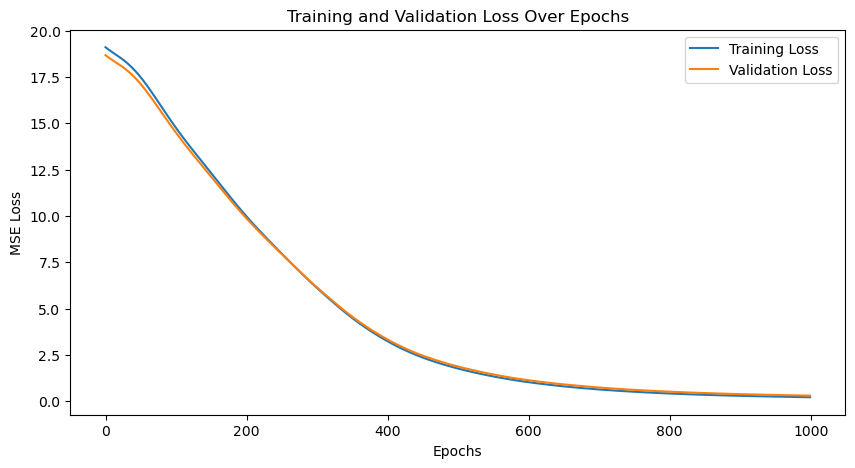

Validation Metrics - MSE: 0.3056, MAE: 0.2306, R2: 0.9835

Fold 6/20
Epoch 20/1000 | Train Loss: 18.4506 | Val Loss: 18.6448
Epoch 40/1000 | Train Loss: 17.7495 | Val Loss: 17.9177
Epoch 60/1000 | Train Loss: 16.7734 | Val Loss: 16.9312
Epoch 80/1000 | Train Loss: 15.6164 | Val Loss: 15.7639
Epoch 100/1000 | Train Loss: 14.4537 | Val Loss: 14.5962
Epoch 120/1000 | Train Loss: 13.4187 | Val Loss: 13.5552
Epoch 140/1000 | Train Loss: 12.5151 | Val Loss: 12.6491
Epoch 160/1000 | Train Loss: 11.6675 | Val Loss: 11.7846
Epoch 180/1000 | Train Loss: 10.8189 | Val Loss: 10.9238
Epoch 200/1000 | Train Loss: 9.9839 | Val Loss: 10.0731
Epoch 220/1000 | Train Loss: 9.1849 | Val Loss: 9.2694
Epoch 240/1000 | Train Loss: 8.4133 | Val Loss: 8.4910
Epoch 260/1000 | Train Loss: 7.6627 | Val Loss: 7.7369
Epoch 280/1000 | Train Loss: 6.9468 | Val Loss: 7.0302
Epoch 300/1000 | Train Loss: 6.2646 | Val Loss: 6.3514
Epoch 320/1000 | Train Loss: 5.6199 | Val Loss: 5.7089
Epoch 340/1000 | Train Loss: 5.0294 

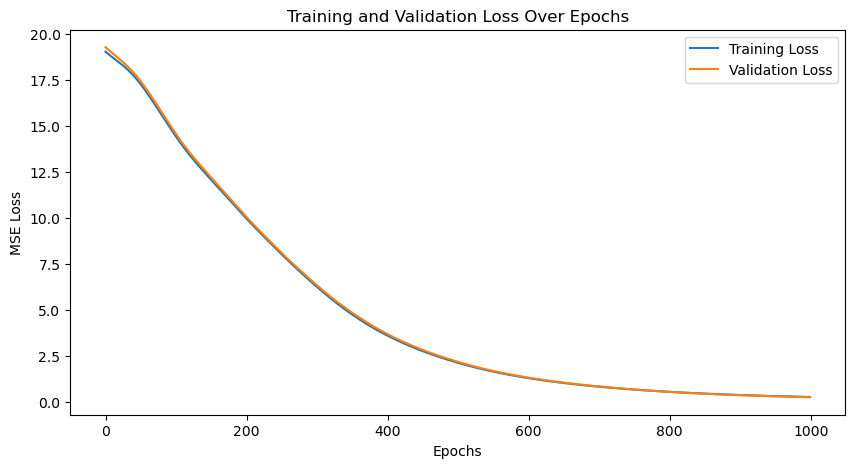

Validation Metrics - MSE: 0.2425, MAE: 0.2333, R2: 0.9874

Fold 7/20
Epoch 20/1000 | Train Loss: 18.3772 | Val Loss: 18.9141
Epoch 40/1000 | Train Loss: 17.5922 | Val Loss: 18.0869
Epoch 60/1000 | Train Loss: 16.5098 | Val Loss: 16.9373
Epoch 80/1000 | Train Loss: 15.2863 | Val Loss: 15.6609
Epoch 100/1000 | Train Loss: 14.1270 | Val Loss: 14.4796
Epoch 120/1000 | Train Loss: 13.1250 | Val Loss: 13.4688
Epoch 140/1000 | Train Loss: 12.2472 | Val Loss: 12.5761
Epoch 160/1000 | Train Loss: 11.4321 | Val Loss: 11.7280
Epoch 180/1000 | Train Loss: 10.6599 | Val Loss: 10.9284
Epoch 200/1000 | Train Loss: 9.9403 | Val Loss: 10.1858
Epoch 220/1000 | Train Loss: 9.2583 | Val Loss: 9.4901
Epoch 240/1000 | Train Loss: 8.5911 | Val Loss: 8.8193
Epoch 260/1000 | Train Loss: 7.8984 | Val Loss: 8.1214
Epoch 280/1000 | Train Loss: 7.1566 | Val Loss: 7.3836
Epoch 300/1000 | Train Loss: 6.3981 | Val Loss: 6.6226
Epoch 320/1000 | Train Loss: 5.6721 | Val Loss: 5.8913
Epoch 340/1000 | Train Loss: 4.9971 

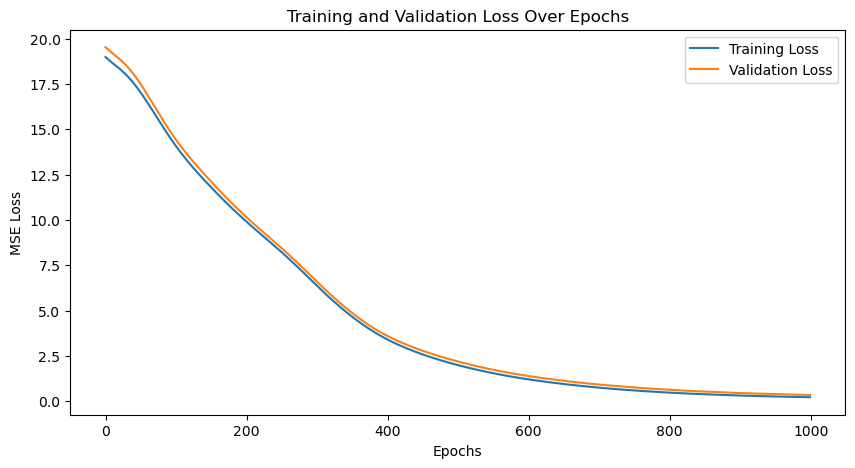

Validation Metrics - MSE: 0.3469, MAE: 0.2223, R2: 0.9823

Fold 8/20
Epoch 20/1000 | Train Loss: 18.6382 | Val Loss: 18.6626
Epoch 40/1000 | Train Loss: 17.9201 | Val Loss: 17.9245
Epoch 60/1000 | Train Loss: 16.9969 | Val Loss: 17.0036
Epoch 80/1000 | Train Loss: 15.8789 | Val Loss: 15.9235
Epoch 100/1000 | Train Loss: 14.7132 | Val Loss: 14.8108
Epoch 120/1000 | Train Loss: 13.5994 | Val Loss: 13.7547
Epoch 140/1000 | Train Loss: 12.5502 | Val Loss: 12.7482
Epoch 160/1000 | Train Loss: 11.5607 | Val Loss: 11.8041
Epoch 180/1000 | Train Loss: 10.6249 | Val Loss: 10.9212
Epoch 200/1000 | Train Loss: 9.7526 | Val Loss: 10.0785
Epoch 220/1000 | Train Loss: 8.9222 | Val Loss: 9.2381
Epoch 240/1000 | Train Loss: 8.1007 | Val Loss: 8.3861
Epoch 260/1000 | Train Loss: 7.2919 | Val Loss: 7.5493
Epoch 280/1000 | Train Loss: 6.5021 | Val Loss: 6.7265
Epoch 300/1000 | Train Loss: 5.7518 | Val Loss: 5.9438
Epoch 320/1000 | Train Loss: 5.0590 | Val Loss: 5.2453
Epoch 340/1000 | Train Loss: 4.4413 

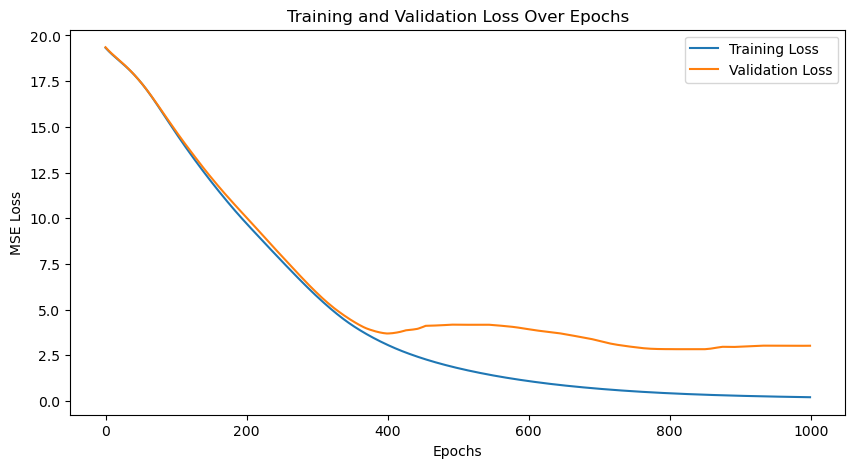

Validation Metrics - MSE: 3.0261, MAE: 0.2314, R2: 0.8404

Fold 9/20
Epoch 20/1000 | Train Loss: 18.5537 | Val Loss: 18.9479
Epoch 40/1000 | Train Loss: 17.8924 | Val Loss: 18.3158
Epoch 60/1000 | Train Loss: 16.9830 | Val Loss: 17.4215
Epoch 80/1000 | Train Loss: 15.8764 | Val Loss: 16.3403
Epoch 100/1000 | Train Loss: 14.7028 | Val Loss: 15.2022
Epoch 120/1000 | Train Loss: 13.5637 | Val Loss: 14.0690
Epoch 140/1000 | Train Loss: 12.4943 | Val Loss: 12.9692
Epoch 160/1000 | Train Loss: 11.4624 | Val Loss: 11.9098
Epoch 180/1000 | Train Loss: 10.4567 | Val Loss: 10.8551
Epoch 200/1000 | Train Loss: 9.4885 | Val Loss: 9.8195
Epoch 220/1000 | Train Loss: 8.5646 | Val Loss: 8.8542
Epoch 240/1000 | Train Loss: 7.6917 | Val Loss: 7.9730
Epoch 260/1000 | Train Loss: 6.9037 | Val Loss: 7.1659
Epoch 280/1000 | Train Loss: 6.1881 | Val Loss: 6.4294
Epoch 300/1000 | Train Loss: 5.5275 | Val Loss: 5.7515
Epoch 320/1000 | Train Loss: 4.9255 | Val Loss: 5.1385
Epoch 340/1000 | Train Loss: 4.3674 |

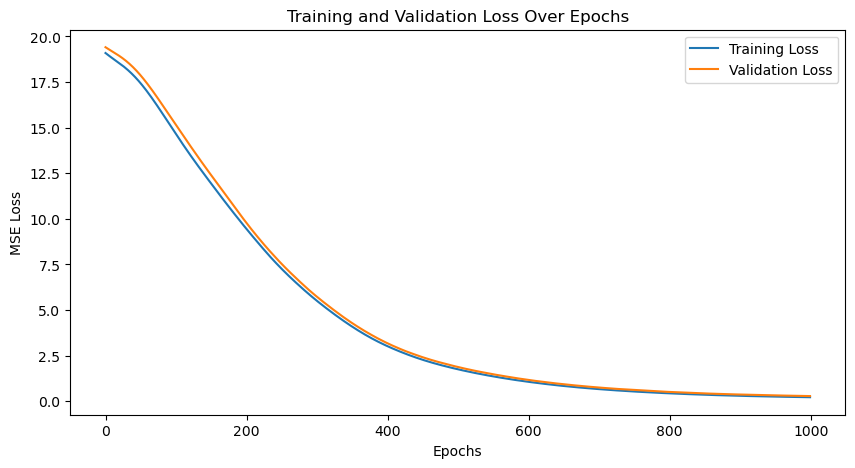

Validation Metrics - MSE: 0.2809, MAE: 0.2209, R2: 0.9855

Fold 10/20
Epoch 20/1000 | Train Loss: 18.5323 | Val Loss: 17.7786
Epoch 40/1000 | Train Loss: 17.7842 | Val Loss: 17.0382
Epoch 60/1000 | Train Loss: 16.7797 | Val Loss: 16.0490
Epoch 80/1000 | Train Loss: 15.6241 | Val Loss: 14.9290
Epoch 100/1000 | Train Loss: 14.4724 | Val Loss: 13.8180
Epoch 120/1000 | Train Loss: 13.4011 | Val Loss: 12.7788
Epoch 140/1000 | Train Loss: 12.3996 | Val Loss: 11.8115
Epoch 160/1000 | Train Loss: 11.4257 | Val Loss: 10.8862
Epoch 180/1000 | Train Loss: 10.4733 | Val Loss: 9.9732
Epoch 200/1000 | Train Loss: 9.5497 | Val Loss: 9.0931
Epoch 220/1000 | Train Loss: 8.6531 | Val Loss: 8.2430
Epoch 240/1000 | Train Loss: 7.7685 | Val Loss: 7.3941
Epoch 260/1000 | Train Loss: 6.9160 | Val Loss: 6.5819
Epoch 280/1000 | Train Loss: 6.1463 | Val Loss: 5.8399
Epoch 300/1000 | Train Loss: 5.4501 | Val Loss: 5.1697
Epoch 320/1000 | Train Loss: 4.8171 | Val Loss: 4.5522
Epoch 340/1000 | Train Loss: 4.2456 |

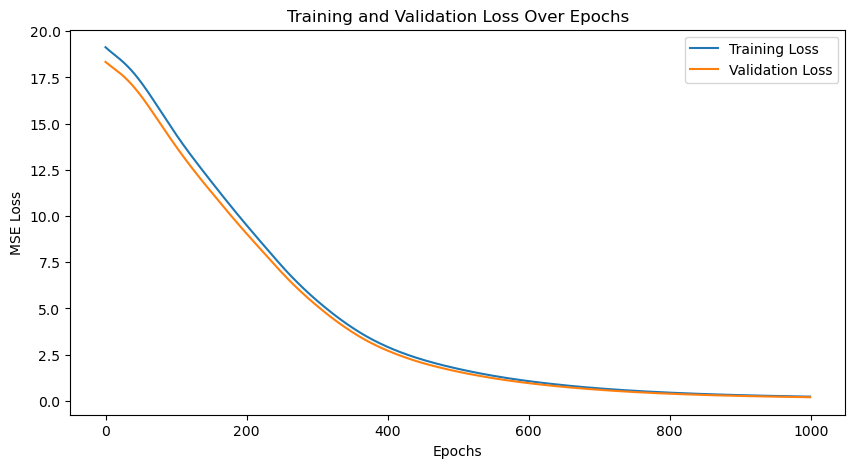

Validation Metrics - MSE: 0.1940, MAE: 0.2045, R2: 0.9894

Fold 11/20
Epoch 20/1000 | Train Loss: 18.6387 | Val Loss: 18.3950
Epoch 40/1000 | Train Loss: 17.9618 | Val Loss: 17.7648
Epoch 60/1000 | Train Loss: 17.0207 | Val Loss: 16.8958
Epoch 80/1000 | Train Loss: 15.8819 | Val Loss: 15.8540
Epoch 100/1000 | Train Loss: 14.6999 | Val Loss: 14.7608
Epoch 120/1000 | Train Loss: 13.5657 | Val Loss: 13.7212
Epoch 140/1000 | Train Loss: 12.5072 | Val Loss: 12.7654
Epoch 160/1000 | Train Loss: 11.5304 | Val Loss: 11.8815
Epoch 180/1000 | Train Loss: 10.6216 | Val Loss: 11.0860
Epoch 200/1000 | Train Loss: 9.7827 | Val Loss: 10.4097
Epoch 220/1000 | Train Loss: 9.0089 | Val Loss: 9.8390
Epoch 240/1000 | Train Loss: 8.2834 | Val Loss: 9.3534
Epoch 260/1000 | Train Loss: 7.5922 | Val Loss: 8.9732
Epoch 280/1000 | Train Loss: 6.8961 | Val Loss: 8.8022
Epoch 300/1000 | Train Loss: 6.1853 | Val Loss: 9.4381
Epoch 320/1000 | Train Loss: 5.5118 | Val Loss: 10.8707
Epoch 340/1000 | Train Loss: 4.898

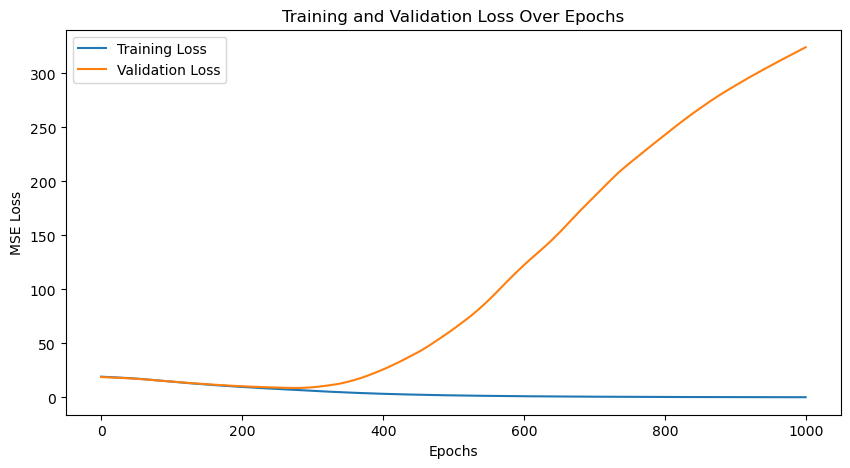

Validation Metrics - MSE: 324.2974, MAE: 0.7211, R2: -16.4064

Fold 12/20
Epoch 20/1000 | Train Loss: 18.4541 | Val Loss: 19.0955
Epoch 40/1000 | Train Loss: 17.7589 | Val Loss: 18.3559
Epoch 60/1000 | Train Loss: 16.7964 | Val Loss: 17.2954
Epoch 80/1000 | Train Loss: 15.6598 | Val Loss: 16.0474
Epoch 100/1000 | Train Loss: 14.5093 | Val Loss: 14.8049
Epoch 120/1000 | Train Loss: 13.4168 | Val Loss: 13.6685
Epoch 140/1000 | Train Loss: 12.3693 | Val Loss: 12.6122
Epoch 160/1000 | Train Loss: 11.3465 | Val Loss: 11.6073
Epoch 180/1000 | Train Loss: 10.3534 | Val Loss: 10.6811
Epoch 200/1000 | Train Loss: 9.4025 | Val Loss: 9.8389
Epoch 220/1000 | Train Loss: 8.5256 | Val Loss: 9.0333
Epoch 240/1000 | Train Loss: 7.7142 | Val Loss: 8.3361
Epoch 260/1000 | Train Loss: 6.9409 | Val Loss: 7.7337
Epoch 280/1000 | Train Loss: 6.2039 | Val Loss: 7.1748
Epoch 300/1000 | Train Loss: 5.5122 | Val Loss: 6.6155
Epoch 320/1000 | Train Loss: 4.8832 | Val Loss: 6.1232
Epoch 340/1000 | Train Loss: 4.3

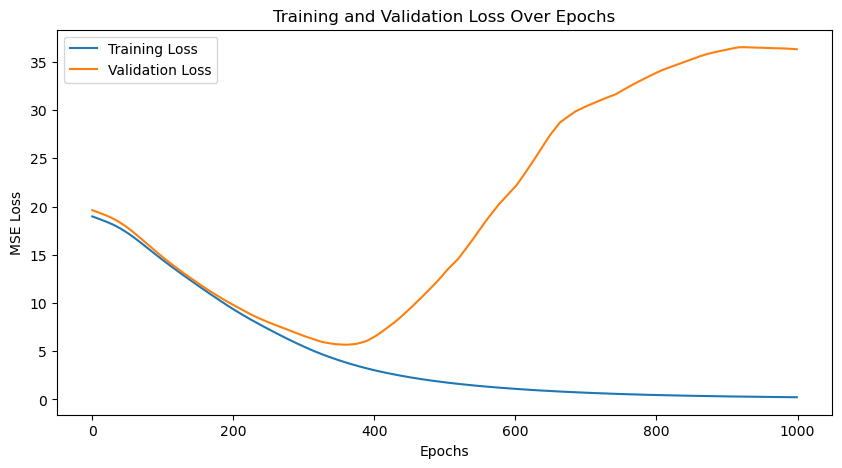

Validation Metrics - MSE: 36.2991, MAE: 0.3223, R2: -0.8529

Fold 13/20
Epoch 20/1000 | Train Loss: 18.5480 | Val Loss: 18.3529
Epoch 40/1000 | Train Loss: 17.8308 | Val Loss: 17.6869
Epoch 60/1000 | Train Loss: 16.8670 | Val Loss: 16.7449
Epoch 80/1000 | Train Loss: 15.7608 | Val Loss: 15.6796
Epoch 100/1000 | Train Loss: 14.6459 | Val Loss: 14.6113
Epoch 120/1000 | Train Loss: 13.5943 | Val Loss: 13.5966
Epoch 140/1000 | Train Loss: 12.5947 | Val Loss: 12.6320
Epoch 160/1000 | Train Loss: 11.5771 | Val Loss: 11.6435
Epoch 180/1000 | Train Loss: 10.5138 | Val Loss: 10.5943
Epoch 200/1000 | Train Loss: 9.4601 | Val Loss: 9.5400
Epoch 220/1000 | Train Loss: 8.4659 | Val Loss: 8.5518
Epoch 240/1000 | Train Loss: 7.5430 | Val Loss: 7.6399
Epoch 260/1000 | Train Loss: 6.7066 | Val Loss: 6.7993
Epoch 280/1000 | Train Loss: 5.9695 | Val Loss: 6.0665
Epoch 300/1000 | Train Loss: 5.3085 | Val Loss: 5.4056
Epoch 320/1000 | Train Loss: 4.7225 | Val Loss: 4.8086
Epoch 340/1000 | Train Loss: 4.203

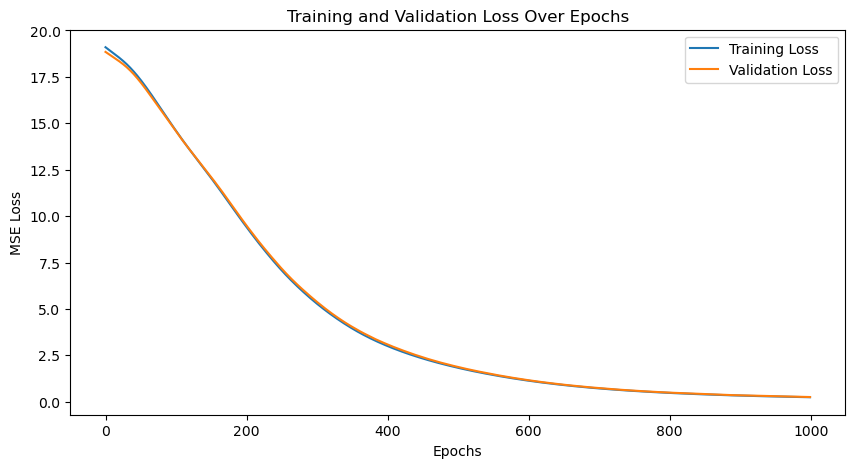

Validation Metrics - MSE: 0.2561, MAE: 0.2338, R2: 0.9864

Fold 14/20
Epoch 20/1000 | Train Loss: 18.4567 | Val Loss: 17.6687
Epoch 40/1000 | Train Loss: 17.6808 | Val Loss: 16.9445
Epoch 60/1000 | Train Loss: 16.6316 | Val Loss: 15.9364
Epoch 80/1000 | Train Loss: 15.4437 | Val Loss: 14.8145
Epoch 100/1000 | Train Loss: 14.2916 | Val Loss: 13.7403
Epoch 120/1000 | Train Loss: 13.2244 | Val Loss: 12.7554
Epoch 140/1000 | Train Loss: 12.2156 | Val Loss: 11.8119
Epoch 160/1000 | Train Loss: 11.2044 | Val Loss: 10.8406
Epoch 180/1000 | Train Loss: 10.1586 | Val Loss: 9.8153
Epoch 200/1000 | Train Loss: 9.1152 | Val Loss: 8.7885
Epoch 220/1000 | Train Loss: 8.1098 | Val Loss: 7.8021
Epoch 240/1000 | Train Loss: 7.1939 | Val Loss: 6.9077
Epoch 260/1000 | Train Loss: 6.3781 | Val Loss: 6.1162
Epoch 280/1000 | Train Loss: 5.6625 | Val Loss: 5.4295
Epoch 300/1000 | Train Loss: 5.0290 | Val Loss: 4.8246
Epoch 320/1000 | Train Loss: 4.4776 | Val Loss: 4.2933
Epoch 340/1000 | Train Loss: 3.9983 |

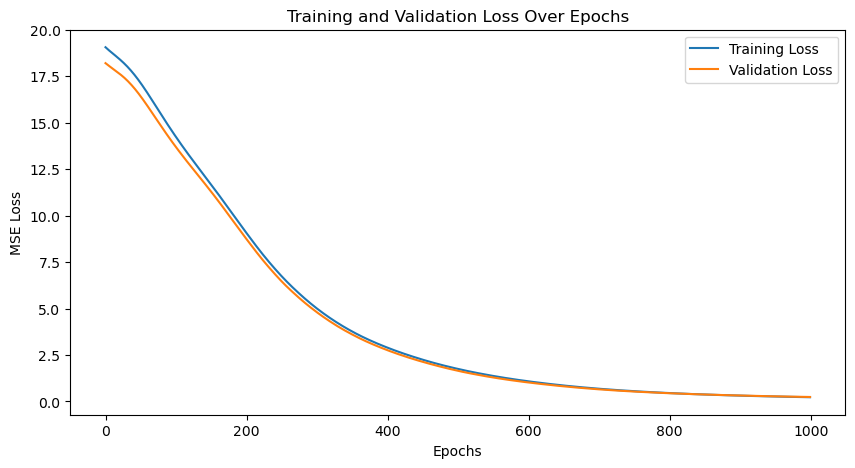

Validation Metrics - MSE: 0.2430, MAE: 0.2045, R2: 0.9867

Fold 15/20
Epoch 20/1000 | Train Loss: 18.3420 | Val Loss: 18.9766
Epoch 40/1000 | Train Loss: 17.5334 | Val Loss: 18.1206
Epoch 60/1000 | Train Loss: 16.4893 | Val Loss: 17.0129
Epoch 80/1000 | Train Loss: 15.3575 | Val Loss: 15.8278
Epoch 100/1000 | Train Loss: 14.2764 | Val Loss: 14.7040
Epoch 120/1000 | Train Loss: 13.3049 | Val Loss: 13.6939
Epoch 140/1000 | Train Loss: 12.4013 | Val Loss: 12.7508
Epoch 160/1000 | Train Loss: 11.5074 | Val Loss: 11.8156
Epoch 180/1000 | Train Loss: 10.6065 | Val Loss: 10.8663
Epoch 200/1000 | Train Loss: 9.7241 | Val Loss: 9.9339
Epoch 220/1000 | Train Loss: 8.8815 | Val Loss: 9.0673
Epoch 240/1000 | Train Loss: 8.0807 | Val Loss: 8.2564
Epoch 260/1000 | Train Loss: 7.3052 | Val Loss: 7.4586
Epoch 280/1000 | Train Loss: 6.5417 | Val Loss: 6.6875
Epoch 300/1000 | Train Loss: 5.8113 | Val Loss: 5.9602
Epoch 320/1000 | Train Loss: 5.1295 | Val Loss: 5.2815
Epoch 340/1000 | Train Loss: 4.5012 

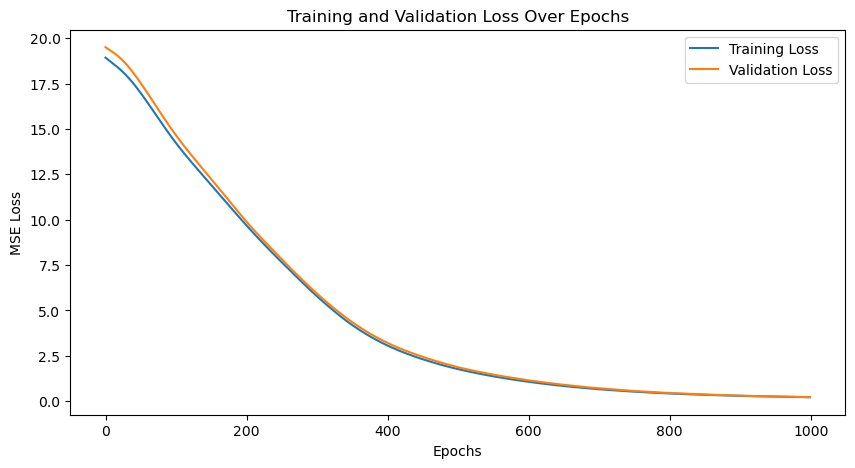

Validation Metrics - MSE: 0.2217, MAE: 0.2122, R2: 0.9887

Fold 16/20
Epoch 20/1000 | Train Loss: 18.4659 | Val Loss: 18.5727
Epoch 40/1000 | Train Loss: 17.7831 | Val Loss: 17.9257
Epoch 60/1000 | Train Loss: 16.8310 | Val Loss: 16.9877
Epoch 80/1000 | Train Loss: 15.7100 | Val Loss: 15.8613
Epoch 100/1000 | Train Loss: 14.5872 | Val Loss: 14.7325
Epoch 120/1000 | Train Loss: 13.5426 | Val Loss: 13.6834
Epoch 140/1000 | Train Loss: 12.5571 | Val Loss: 12.6938
Epoch 160/1000 | Train Loss: 11.5835 | Val Loss: 11.7087
Epoch 180/1000 | Train Loss: 10.6010 | Val Loss: 10.7231
Epoch 200/1000 | Train Loss: 9.6386 | Val Loss: 9.7662
Epoch 220/1000 | Train Loss: 8.7389 | Val Loss: 8.8730
Epoch 240/1000 | Train Loss: 7.8863 | Val Loss: 8.0209
Epoch 260/1000 | Train Loss: 7.0702 | Val Loss: 7.1967
Epoch 280/1000 | Train Loss: 6.3040 | Val Loss: 6.4251
Epoch 300/1000 | Train Loss: 5.6035 | Val Loss: 5.7152
Epoch 320/1000 | Train Loss: 4.9690 | Val Loss: 5.0722
Epoch 340/1000 | Train Loss: 4.4063 

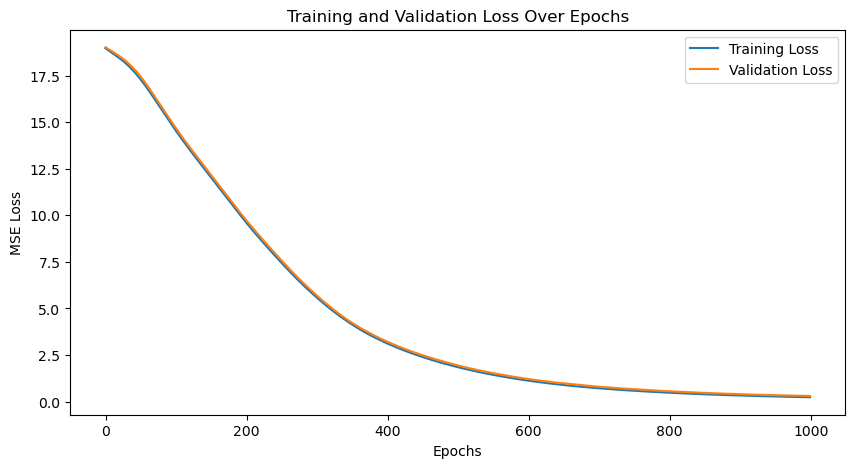

Validation Metrics - MSE: 0.2997, MAE: 0.2249, R2: 0.9843

Fold 17/20
Epoch 20/1000 | Train Loss: 18.5536 | Val Loss: 17.8376
Epoch 40/1000 | Train Loss: 17.8428 | Val Loss: 17.0903
Epoch 60/1000 | Train Loss: 16.8736 | Val Loss: 16.0748
Epoch 80/1000 | Train Loss: 15.7044 | Val Loss: 14.8714
Epoch 100/1000 | Train Loss: 14.5012 | Val Loss: 13.6622
Epoch 120/1000 | Train Loss: 13.3607 | Val Loss: 12.5464
Epoch 140/1000 | Train Loss: 12.2582 | Val Loss: 11.4901
Epoch 160/1000 | Train Loss: 11.1729 | Val Loss: 10.4588
Epoch 180/1000 | Train Loss: 10.1214 | Val Loss: 9.4778
Epoch 200/1000 | Train Loss: 9.1381 | Val Loss: 8.5905
Epoch 220/1000 | Train Loss: 8.2434 | Val Loss: 7.7952
Epoch 240/1000 | Train Loss: 7.4423 | Val Loss: 7.0755
Epoch 260/1000 | Train Loss: 6.7105 | Val Loss: 6.4017
Epoch 280/1000 | Train Loss: 6.0502 | Val Loss: 5.7931
Epoch 300/1000 | Train Loss: 5.4538 | Val Loss: 5.2371
Epoch 320/1000 | Train Loss: 4.9088 | Val Loss: 4.7272
Epoch 340/1000 | Train Loss: 4.4137 |

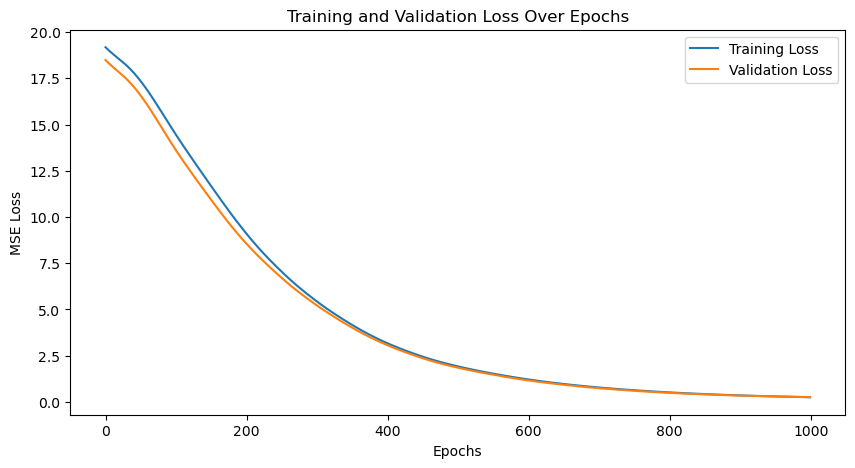

Validation Metrics - MSE: 0.2579, MAE: 0.2257, R2: 0.9859

Fold 18/20
Epoch 20/1000 | Train Loss: 18.2958 | Val Loss: 18.7192
Epoch 40/1000 | Train Loss: 17.4692 | Val Loss: 17.8287
Epoch 60/1000 | Train Loss: 16.4493 | Val Loss: 16.7409
Epoch 80/1000 | Train Loss: 15.3811 | Val Loss: 15.6068
Epoch 100/1000 | Train Loss: 14.3747 | Val Loss: 14.5487
Epoch 120/1000 | Train Loss: 13.4766 | Val Loss: 13.6258
Epoch 140/1000 | Train Loss: 12.6334 | Val Loss: 12.7692
Epoch 160/1000 | Train Loss: 11.7670 | Val Loss: 11.9007
Epoch 180/1000 | Train Loss: 10.8623 | Val Loss: 11.0115
Epoch 200/1000 | Train Loss: 9.9371 | Val Loss: 10.1046
Epoch 220/1000 | Train Loss: 8.9893 | Val Loss: 9.1759
Epoch 240/1000 | Train Loss: 8.0413 | Val Loss: 8.2324
Epoch 260/1000 | Train Loss: 7.1238 | Val Loss: 7.3457
Epoch 280/1000 | Train Loss: 6.2809 | Val Loss: 6.5617
Epoch 300/1000 | Train Loss: 5.5174 | Val Loss: 5.8648
Epoch 320/1000 | Train Loss: 4.8262 | Val Loss: 5.2157
Epoch 340/1000 | Train Loss: 4.2180

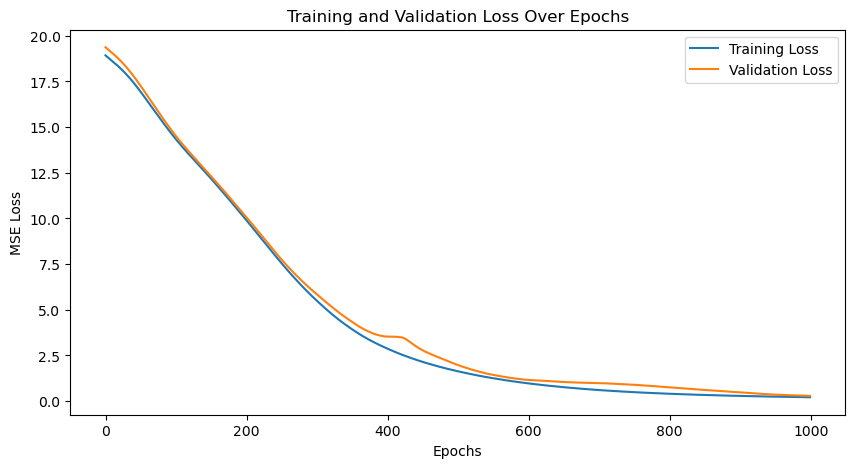

Validation Metrics - MSE: 0.2865, MAE: 0.2186, R2: 0.9853

Fold 19/20
Epoch 20/1000 | Train Loss: 18.5457 | Val Loss: 18.3307
Epoch 40/1000 | Train Loss: 17.8381 | Val Loss: 17.6388
Epoch 60/1000 | Train Loss: 16.8551 | Val Loss: 16.6680
Epoch 80/1000 | Train Loss: 15.7001 | Val Loss: 15.5342
Epoch 100/1000 | Train Loss: 14.5509 | Val Loss: 14.4240
Epoch 120/1000 | Train Loss: 13.4816 | Val Loss: 13.3954
Epoch 140/1000 | Train Loss: 12.5079 | Val Loss: 12.4635
Epoch 160/1000 | Train Loss: 11.5979 | Val Loss: 11.5884
Epoch 180/1000 | Train Loss: 10.6969 | Val Loss: 10.7238
Epoch 200/1000 | Train Loss: 9.8046 | Val Loss: 9.8641
Epoch 220/1000 | Train Loss: 8.9335 | Val Loss: 9.0056
Epoch 240/1000 | Train Loss: 8.0907 | Val Loss: 8.1538
Epoch 260/1000 | Train Loss: 7.2744 | Val Loss: 7.3303
Epoch 280/1000 | Train Loss: 6.4608 | Val Loss: 6.4950
Epoch 300/1000 | Train Loss: 5.6663 | Val Loss: 5.7005
Epoch 320/1000 | Train Loss: 4.9443 | Val Loss: 4.9800
Epoch 340/1000 | Train Loss: 4.3208 

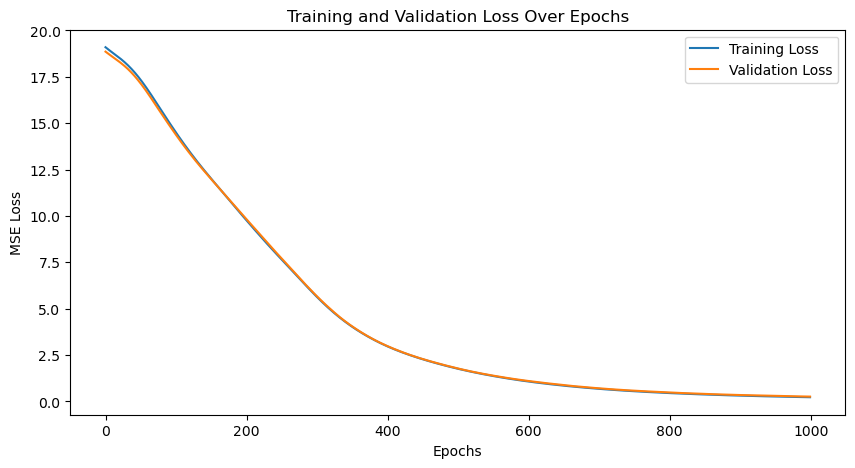

Validation Metrics - MSE: 0.2633, MAE: 0.2322, R2: 0.9860

Fold 20/20
Epoch 20/1000 | Train Loss: 18.5336 | Val Loss: 18.7568
Epoch 40/1000 | Train Loss: 17.8066 | Val Loss: 17.9980
Epoch 60/1000 | Train Loss: 16.8054 | Val Loss: 16.9269
Epoch 80/1000 | Train Loss: 15.6489 | Val Loss: 15.7196
Epoch 100/1000 | Train Loss: 14.4780 | Val Loss: 14.5078
Epoch 120/1000 | Train Loss: 13.3696 | Val Loss: 13.3693
Epoch 140/1000 | Train Loss: 12.3142 | Val Loss: 12.2857
Epoch 160/1000 | Train Loss: 11.2632 | Val Loss: 11.2088
Epoch 180/1000 | Train Loss: 10.2098 | Val Loss: 10.1527
Epoch 200/1000 | Train Loss: 9.1907 | Val Loss: 9.1416
Epoch 220/1000 | Train Loss: 8.2224 | Val Loss: 8.1896
Epoch 240/1000 | Train Loss: 7.3327 | Val Loss: 7.3124
Epoch 260/1000 | Train Loss: 6.5024 | Val Loss: 6.4943
Epoch 280/1000 | Train Loss: 5.7257 | Val Loss: 5.7451
Epoch 300/1000 | Train Loss: 5.0121 | Val Loss: 5.0577
Epoch 320/1000 | Train Loss: 4.3859 | Val Loss: 4.4572
Epoch 340/1000 | Train Loss: 3.8500 

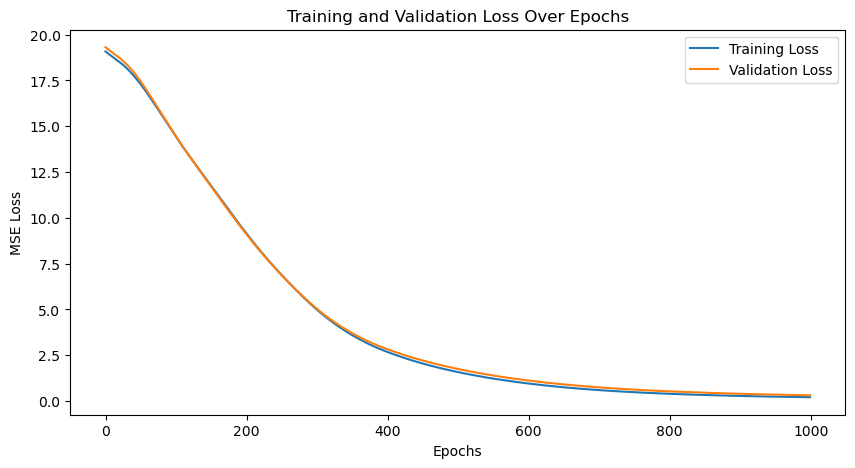

Validation Metrics - MSE: 0.3104, MAE: 0.2216, R2: 0.9838

Cross-Validation Summary:
Average MSE: 18.4106
Average MAE: 0.2531
Average R2: 0.0170
Best Model MSE: 0.1795


In [21]:
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)

# K-Fold Cross Validation on Training Data
print("\nRunning K-Fold Cross Validation:")
results = kfold_cross_validation(x_train, y_train) #20 folds

Epoch 20/1000 | Train Loss: 18.3898 | Val Loss: 18.3510
Epoch 40/1000 | Train Loss: 17.6587 | Val Loss: 17.6238
Epoch 60/1000 | Train Loss: 16.7053 | Val Loss: 16.6626
Epoch 80/1000 | Train Loss: 15.5865 | Val Loss: 15.5427
Epoch 100/1000 | Train Loss: 14.4630 | Val Loss: 14.4297
Epoch 120/1000 | Train Loss: 13.4406 | Val Loss: 13.4190
Epoch 140/1000 | Train Loss: 12.5235 | Val Loss: 12.5066
Epoch 160/1000 | Train Loss: 11.6544 | Val Loss: 11.6360
Epoch 180/1000 | Train Loss: 10.8236 | Val Loss: 10.7994
Epoch 200/1000 | Train Loss: 10.0426 | Val Loss: 10.0129
Epoch 220/1000 | Train Loss: 9.2902 | Val Loss: 9.2580
Epoch 240/1000 | Train Loss: 8.5691 | Val Loss: 8.5370
Epoch 260/1000 | Train Loss: 7.8855 | Val Loss: 7.8536
Epoch 280/1000 | Train Loss: 7.2272 | Val Loss: 7.1952
Epoch 300/1000 | Train Loss: 6.5937 | Val Loss: 6.5649
Epoch 320/1000 | Train Loss: 5.9737 | Val Loss: 5.9484
Epoch 340/1000 | Train Loss: 5.3688 | Val Loss: 5.3451
Epoch 360/1000 | Train Loss: 4.7927 | Val Loss: 4

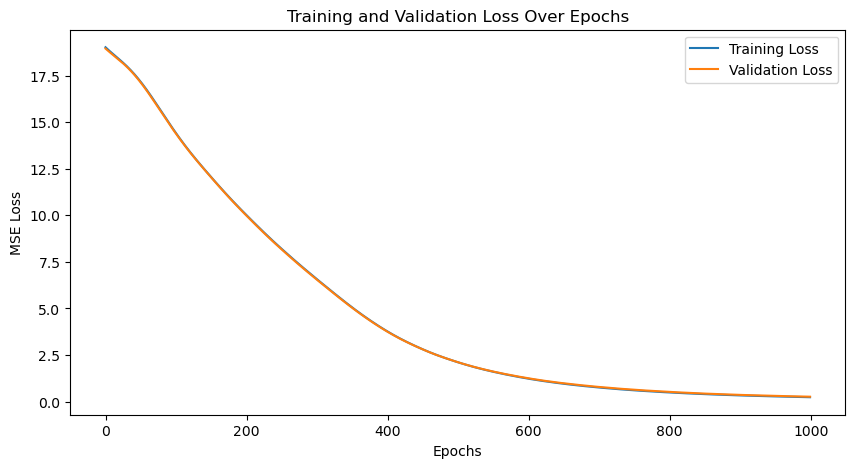


Evaluation Metrics:
MSE: 0.2609
MAE: 0.2298
R2 Score: 0.9862


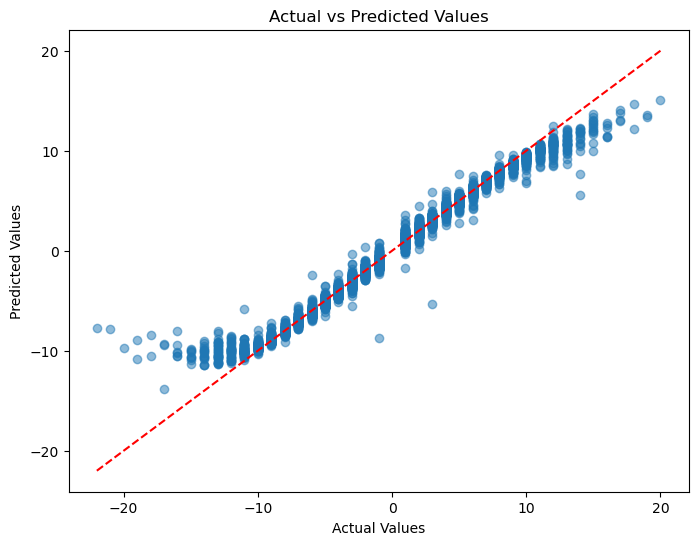

In [22]:
model = train_model(x_train, y_train, x_test, y_test, n_epochs=1000) 

#the model is not training on the x_test, y_test these are validation params required by the implmentatioin
#of training

evaluate_model(model, x_test, y_test) #uses the best model from the kfold evaluation based on mse

#MAE is less sensitive to outliers
#MSE penalizes large errors more

In [221]:
#The model is good for predicting score difference but its a black box so its not as good
#at explaining the why. This is a large disadvantage for the use of sports analytics if your intent is to use it for 
#sport scouting or team building.

#only 1 hidden layer to prevent overfitting